# Imports & Setup

In [1]:
import os
import sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
import re
import json
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)
from transformers import AutoTokenizer, AutoModel
from torch.amp import autocast, GradScaler

# ---------------- CFG ----------------
SEED = 42
DATA_PATH = "../../datasets/url_feeds/processed/final_urls.csv"
OUT_DIR = "url_charcnn_stage3_model"

# If you want to train on a subset for quick experiments:
USE_SUBSAMPLE = False           # <- set True for debug / fast runs
SUBSAMPLE_N = 2_000_000         # number of rows to keep if subsampling

MAX_LEN = 512                   # URL char sequence length
BATCH_SIZE = 256                # adjust if you hit OOM
NUM_EPOCHS = 4                  # with 10M+ rows, 2–4 epochs is usually enough
EMBED_DIM = 160                 # char embedding size
NUM_FILTERS = 320               # conv filters per kernel size
KERNEL_SIZES = (3,5,7,11,15)    # you can add 9 / 11 later
DROPOUT = 0.3
LR = 5e-4
WEIGHT_DECAY = 0.01

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)


/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cuda


# URL Normalization Helpers

In [2]:
try:
    from utils.helpers.url_filter import normalize_url_min
except Exception:
    # Fallback: minimal normalization compatible with your builder logic
    from urllib.parse import urlparse

    def normalize_url_min(u: str) -> str:
        if not isinstance(u, str):
            return ""
        u = u.strip()
        u = u.replace("\\n", "").replace("\\r", "")
        u = re.sub(r"\s+", "", u)
        u = u.lower()
        # strip protocol
        u = re.sub(r"^https?://", "", u)
        # strip leading www.
        u = re.sub(r"^www\.", "", u)
        # drop trailing slash only
        if u.endswith("/"):
            u = u[:-1]
        return u

print("Using normalize_url_min from:", normalize_url_min.__module__)

Using normalize_url_min from: utils.helpers.url_filter


# Load unified CSV and build URL subset

In [3]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Final URL dataset not found at: {DATA_PATH}")

print(f"\n[INFO] Loading Stage-3 dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, dtype={"url": str, "label": int})

print(f"[INFO] Raw rows loaded: {len(df):,}")
print("[INFO] Label distribution (raw):")
print(df["label"].value_counts())

# Ensure correct dtypes
df["url"] = df["url"].astype(str)
df["label"] = df["label"].astype(int)

# Optional subsample
if USE_SUBSAMPLE and len(df) > SUBSAMPLE_N:
    df = df.sample(n=SUBSAMPLE_N, random_state=SEED).reset_index(drop=True)
    print(f"[INFO] Subsampled dataset to {len(df):,} rows for training debug.")

# Normalize into urls_norm
df["urls_norm"] = df["url"].apply(normalize_url_min)
df = df[df["urls_norm"].str.len() > 0].reset_index(drop=True)

print(f"[INFO] Rows after dropping empty normalized URLs: {len(df):,}")
print("[INFO] Label distribution AFTER normalization:")
print(df["label"].value_counts())



[INFO] Loading Stage-3 dataset from: ../../datasets/url_feeds/processed/final_urls.csv
[INFO] Raw rows loaded: 10,684,070
[INFO] Label distribution (raw):
label
0    5522517
1    5161553
Name: count, dtype: int64
[INFO] Rows after dropping empty normalized URLs: 10,684,070
[INFO] Label distribution AFTER normalization:
label
0    5522517
1    5161553
Name: count, dtype: int64


# Train/Val split

In [4]:
train_df, val_df = train_test_split(
    df[["urls_norm", "label"]],
    test_size=0.05,               # 5% for validation
    random_state=SEED,
    stratify=df["label"],
)

print(f"\n[INFO] Train size: {len(train_df):,}")
print(f"[INFO] Val size:   {len(val_df):,}")
print("[INFO] Train label dist:")
print(train_df["label"].value_counts())
print("[INFO] Val label dist:")
print(val_df["label"].value_counts())


[INFO] Train size: 10,149,866
[INFO] Val size:   534,204
[INFO] Train label dist:
label
0    5246391
1    4903475
Name: count, dtype: int64
[INFO] Val label dist:
label
0    276126
1    258078
Name: count, dtype: int64


# Character vocabulary construction

In [5]:
def build_char_vocab(series, extra_chars=None):
    chars = set()
    for text in series:
        for ch in text:
            chars.add(ch)

    if extra_chars:
        chars.update(extra_chars)

    sorted_chars = sorted(chars)
    char2idx = {"<PAD>": 0, "<UNK>": 1}
    idx2char = {0: "<PAD>", 1: "<UNK>"}
    for i, ch in enumerate(sorted_chars, start=2):
        char2idx[ch] = i
        idx2char[i] = ch

    return char2idx, idx2char

# Build vocab from training only
char2idx, idx2char = build_char_vocab(train_df["urls_norm"])
vocab_size = len(char2idx)
print("\n[INFO] Vocab size (incl. PAD/UNK):", vocab_size)

# Save vocab
os.makedirs(OUT_DIR, exist_ok=True)
with open(os.path.join(OUT_DIR, "char_vocab.json"), "w", encoding="utf-8") as f:
    json.dump(char2idx, f, ensure_ascii=False, indent=2)


[INFO] Vocab size (incl. PAD/UNK): 266


# URL encoding helpers

In [6]:
def encode_url_text(text, char2idx, max_len=MAX_LEN):
    text = str(text)
    ids = []
    for ch in text:
        idx = char2idx.get(ch, char2idx["<UNK>"])
        ids.append(idx)
        if len(ids) >= max_len:
            break
    if len(ids) < max_len:
        ids = ids + [char2idx["<PAD>"]] * (max_len - len(ids))
    return np.array(ids, dtype=np.int64)

# quick sanity check
ex_url = train_df["urls_norm"].iloc[0]
print("\n[DEBUG] Example URL:", ex_url[:120], "...")
print("[DEBUG] Encoded first 20:", encode_url_text(ex_url, char2idx)[:20])


[DEBUG] Example URL: pornmate.tv ...
[DEBUG] Encoded first 20: [77 76 79 75 74 62 81 66 37 81 83  0  0  0  0  0  0  0  0  0]


# PyTorch Dataset & DataLoaders

In [7]:
class UrlDataset(Dataset):
    def __init__(self, df, char2idx, max_len=MAX_LEN):
        # normalized URL string used for both char and transformer
        self.texts = df["urls_norm"].tolist()
        self.labels = df["label"].astype(int).tolist()
        self.char2idx = char2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        input_ids = encode_url_text(text, self.char2idx, self.max_len)
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(label, dtype=torch.long),
            "text": text,  # <-- NEW: raw normalized URL string
        }

train_dataset = UrlDataset(train_df, char2idx, MAX_LEN)
val_dataset   = UrlDataset(val_df,   char2idx, MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print("\n[INFO] Train batches:", len(train_loader))
print("[INFO] Val batches:  ", len(val_loader))


[INFO] Train batches: 39648
[INFO] Val batches:   2087


# Residual block + attention pool

In [8]:
class CharResBlock(nn.Module):
    """
    Residual 1D Conv block:
      Conv1d -> ReLU -> Conv1d + skip connection
    Input/Output: [B, C, L]
    """
    def __init__(self, channels, kernel_size, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2  # "same-ish" padding
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()

    def forward(self, x):
        # x: [B, C, L]
        residual = x
        out = self.conv1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = out + residual
        out = self.activation(out)
        return out


class SelfAttentionPool(nn.Module):
    """
    Simple self-attention pooling over time.
    Input:  [B, C, L]
    Output: [B, C]
    """
    def __init__(self, channels):
        super().__init__()
        self.att_proj = nn.Linear(channels, 1)

    def forward(self, x):
        # x: [B, C, L]
        # -> [B, L, C]
        x_perm = x.transpose(1, 2)
        # attention scores: [B, L, 1]
        scores = self.att_proj(x_perm)
        weights = torch.softmax(scores, dim=1)  # [B, L, 1]
        # weighted sum
        pooled = (x_perm * weights).sum(dim=1)  # [B, C]
        return pooled

# CharCNNEncoder Model Definition

In [9]:
class CharCNNEncoder(nn.Module):
    """
    char-level encoder:
      - embedding
      - multi-kernel Conv1d
      - residual refinement
      - attention pooling over time
    Returns: [B, hidden_dim]
    """
    def __init__(
        self,
        vocab_size,
        embed_dim=128,            # upgraded from 64
        num_filters=256,          # upgraded from 128
        kernel_sizes=(3, 5, 7, 11, 15),
        padding_idx=0,
        dropout=0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k,
                padding=k // 2,
            )
            for k in kernel_sizes
        ])

        # Residual blocks AFTER concatenating all conv outputs
        self.res_blocks = nn.ModuleList([
            CharResBlock(num_filters * len(kernel_sizes), kernel_size=3, dropout=dropout),
            CharResBlock(num_filters * len(kernel_sizes), kernel_size=5, dropout=dropout),
        ])

        self.att_pool = SelfAttentionPool(num_filters * len(kernel_sizes))
        self.dropout = nn.Dropout(dropout)

        self.output_dim = num_filters * len(kernel_sizes)  # for fusion later

    def forward(self, input_ids):
        # input_ids: [B, L]
        x = self.embedding(input_ids)  # [B, L, E]
        x = x.transpose(1, 2)          # [B, E, L]

        conv_outputs = []
        for conv in self.convs:
            h = conv(x)                # [B, F, L]
            h = torch.relu(h)
            conv_outputs.append(h)

        # concat over filter dimension
        z = torch.cat(conv_outputs, dim=1)  # [B, F * num_kernels, L]

        # residual refinement
        for block in self.res_blocks:
            z = block(z)                     # [B, F * num_kernels, L]

        # attention pooling over time
        pooled = self.att_pool(z)            # [B, F * num_kernels]
        pooled = self.dropout(pooled)
        return pooled  # feature vector

# Hybrid model: CharCNNEncoder + DistilBERT

In [10]:
TRANSFORMER_NAME = "distilbert-base-uncased"
URL_MAX_TOKENS = 64  # URL strings are short; 32–64 is enough

# init tokenizer & transformer backbone
url_tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_NAME)
transformer_backbone = AutoModel.from_pretrained(TRANSFORMER_NAME)


class HybridCharTransformer(nn.Module):
    """
    Hybrid URL classifier:
      - CharCNNEncoder over characters
      - DistilBERT (or similar) over whole URL text
      - Concatenate features + final classifier
    """
    def __init__(
        self,
        vocab_size,
        num_classes=2,
        embed_dim=128,
        num_filters=256,
        kernel_sizes=(3, 5, 7, 11, 15),
        padding_idx=0,
        dropout=0.3,
        transformer_model=None,
    ):
        super().__init__()

        # char encoder
        self.char_encoder = CharCNNEncoder(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            num_filters=num_filters,
            kernel_sizes=kernel_sizes,
            padding_idx=padding_idx,
            dropout=dropout,
        )

        # transformer encoder
        self.transformer = transformer_model if transformer_model is not None else transformer_backbone

        # hidden sizes
        char_dim = self.char_encoder.output_dim
        transf_dim = self.transformer.config.hidden_size

        fusion_dim = char_dim + transf_dim

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, char_ids, input_ids, attention_mask):
        """
        char_ids:      [B, Lc]  (char indices)
        input_ids:     [B, Lt]  (transformer token ids)
        attention_mask:[B, Lt]
        """
        # 1) Char encoder
        char_feat = self.char_encoder(char_ids)  # [B, Cc]

        # 2) Transformer encoder (DistilBERT)
        transf_out = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )  # last_hidden_state: [B, Lt, H]
        last_hidden = transf_out.last_hidden_state

        # mean-pool over tokens
        mask = attention_mask.unsqueeze(-1)  # [B, Lt, 1]
        masked_hidden = last_hidden * mask
        summed = masked_hidden.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)
        transf_feat = summed / lengths       # [B, H]

        # 3) fuse
        fused = torch.cat([char_feat, transf_feat], dim=1)  # [B, Cc+H]

        # 4) classifier
        logits = self.classifier(fused)  # [B, 2]
        return logits

# Initialize Model

In [11]:
model = HybridCharTransformer(
    vocab_size=vocab_size,
    num_classes=2,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    padding_idx=char2idx["<PAD>"],
    dropout=DROPOUT,
    transformer_model=transformer_backbone,
).to(device)

print("\n[INFO] Model parameters:", sum(p.numel() for p in model.parameters()))



[INFO] Model parameters: 110688195


# Training Setup

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

# OneCycleLR – good for large corpora
steps_per_epoch = len(train_loader)
max_steps = steps_per_epoch * NUM_EPOCHS
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    total_steps=max_steps,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=25.0,
    final_div_factor=1e4,
)

def evaluate(model, data_loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            char_ids = batch["input_ids"].to(device)
            labels   = batch["labels"].to(device)
            texts    = batch["text"]  # list of strings

            # tokenize URLs for transformer branch
            enc = url_tokenizer(
                texts,
                padding=True,
                truncation=True,
                max_length=URL_MAX_TOKENS,
                return_tensors="pt",
            ).to(device)

            with autocast(enabled=(device == "cuda")):
                logits = model(
                    char_ids=char_ids,
                    input_ids=enc["input_ids"],
                    attention_mask=enc["attention_mask"],
                )
                probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
    }

# Training Loop

In [13]:
train_history = []
best_f1 = 0.0
best_state_dict = None
global_step = 0

scaler = GradScaler(device=device)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    num_batches = 0

    for batch in train_loader:
        char_ids = batch["input_ids"].to(device)
        labels   = batch["labels"].to(device)
        texts    = batch["text"]  # list of strings

        # tokenize URLs
        enc = url_tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=URL_MAX_TOKENS,
            return_tensors="pt",
        ).to(device)

        optimizer.zero_grad()

        with autocast(device_type=device):
            logits = model(
                char_ids=char_ids,
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"],
            )
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        num_batches += 1
        global_step += 1

        if global_step % 500 == 0:
            print(f"[STEP {global_step}] loss={loss.item():.4f}")

    avg_train_loss = running_loss / max(1, num_batches)

    metrics = evaluate(model, val_loader, device)
    val_acc  = metrics["accuracy"]
    val_prec = metrics["precision"]
    val_rec  = metrics["recall"]
    val_f1   = metrics["f1"]

    train_history.append({
        "epoch": epoch,
        "train_loss": avg_train_loss,
        "val_accuracy": val_acc,
        "val_precision": val_prec,
        "val_recall": val_rec,
        "val_f1": val_f1,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Prec: {val_prec:.4f} | "
        f"Val Rec: {val_rec:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state_dict = model.state_dict()

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"\n[INFO] Loaded best model (F1={best_f1:.4f})")

[STEP 500] loss=0.5670
[STEP 1000] loss=0.4534
[STEP 1500] loss=0.4298
[STEP 2000] loss=0.4798
[STEP 2500] loss=0.4438
[STEP 3000] loss=0.4216
[STEP 3500] loss=0.4883
[STEP 4000] loss=0.4499
[STEP 4500] loss=0.4307
[STEP 5000] loss=0.4725
[STEP 5500] loss=0.4880


KeyboardInterrupt: 

# Save Model

In [ ]:
# os.makedirs(OUT_DIR, exist_ok=True)
# torch.save(model.state_dict(), os.path.join(OUT_DIR, "model.pt"))
# print(f"[OK] Saved CharCNN model to {OUT_DIR}/model.pt")

# Training Curves


[INFO] Training history:
   epoch  train_loss  val_accuracy  val_precision  val_recall    val_f1
0      1    0.545860      0.736427       0.765326    0.655383  0.706100
1      2    0.513844      0.741945       0.781402    0.646781  0.707747
2      3    0.507248      0.744526       0.789169    0.642957  0.708599
3      4    0.503448      0.746563       0.771233    0.675889  0.720420
4      5    0.500234      0.748235       0.781377    0.664896  0.718446
5      6    0.497154      0.749461       0.785042    0.662920  0.718831
6      7    0.494053      0.750730       0.784737    0.666992  0.721090
7      8    0.491558      0.751782       0.782579    0.673254  0.723811
8      9    0.489973      0.751864       0.784214    0.671014  0.723211


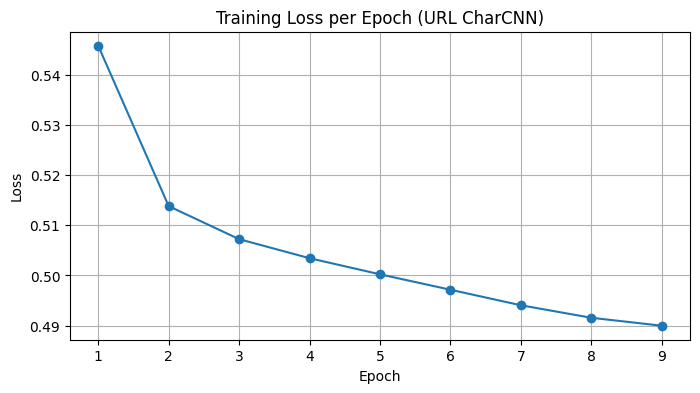

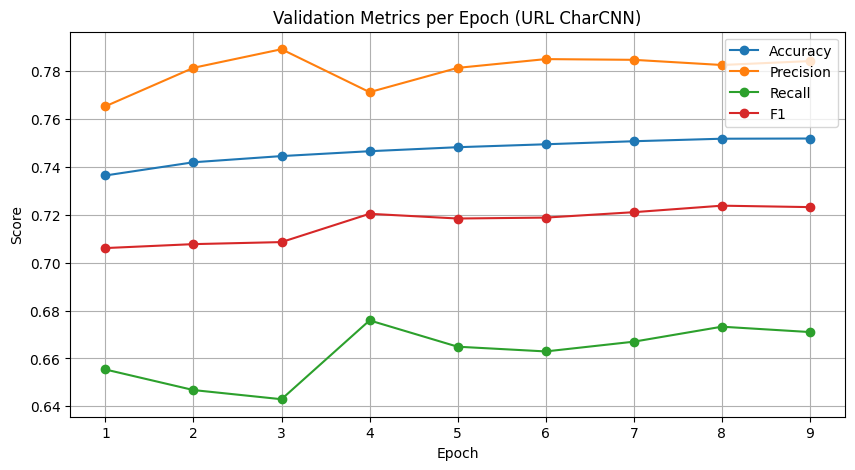

In [ ]:
hist_df = pd.DataFrame(train_history)
print("\n[INFO] Training history:")
print(hist_df)

plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], marker="o")
plt.title("Training Loss per Epoch (URL CharCNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for col, label in [
    ("val_accuracy", "Accuracy"),
    ("val_precision", "Precision"),
    ("val_recall", "Recall"),
    ("val_f1", "F1"),
]:
    if col in hist_df:
        plt.plot(hist_df["epoch"], hist_df[col], marker="o", label=label)

plt.title("Validation Metrics per Epoch (URL CharCNN)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Final Confusion Matrix & Classification Report

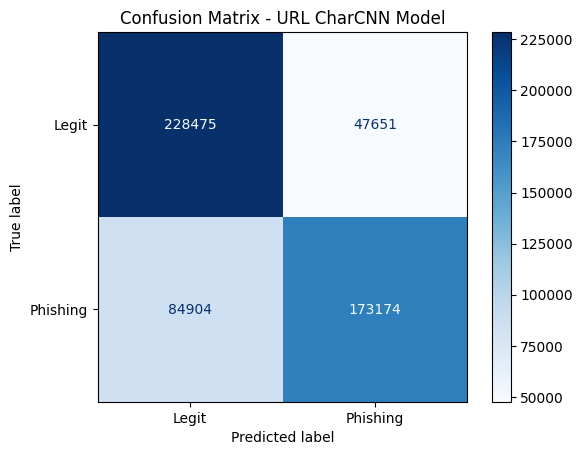


Classification Report (URL CharCNN):
              precision    recall  f1-score   support

       Legit       0.73      0.83      0.78    276126
    Phishing       0.78      0.67      0.72    258078

    accuracy                           0.75    534204
   macro avg       0.76      0.75      0.75    534204
weighted avg       0.76      0.75      0.75    534204



In [ ]:
final_metrics = evaluate(model, val_loader, device)
y_true = final_metrics["labels"]
y_pred = final_metrics["preds"]

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - URL CharCNN Model")
plt.show()

print("\nClassification Report (URL CharCNN):")
print(classification_report(y_true, y_pred, target_names=["Legit", "Phishing"]))

# Precision–Recall Curve

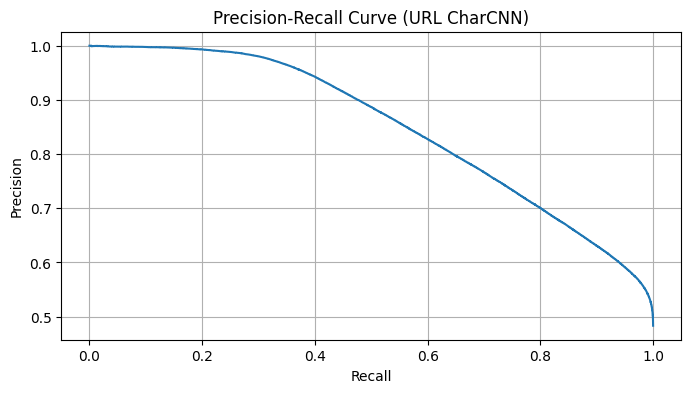

In [ ]:
y_probs = final_metrics["probs"]
prec, rec, thresh = precision_recall_curve(y_true, y_probs)

plt.figure(figsize=(8, 4))
plt.plot(rec, prec)
plt.title("Precision-Recall Curve (URL CharCNN)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


# Threshold Tuning Module

In [ ]:
def collect_val_probs(model, val_loader, device):
    model.eval()
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels    = batch["labels"].cpu().numpy()

            logits = model(input_ids)
            probs  = torch.softmax(logits, dim=1)[:,1]   # phishing prob

            all_labels.extend(labels)
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)


# 1) Collect validation probabilities
y_true, y_prob = collect_val_probs(model, val_loader, device)

print(f"[INFO] Collected {len(y_true)} validation samples")


# 2) Sweep thresholds
thresholds = np.linspace(0.05, 0.95, 91)  # step = 0.01
results = []

best_f1 = 0
best_threshold = 0.5

for th in thresholds:
    preds = (y_prob >= th).astype(int)

    acc  = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="binary", zero_division=0
    )

    results.append([th, acc, prec, rec, f1])

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

th_df = pd.DataFrame(results, columns=["threshold", "accuracy", "precision", "recall", "f1"])

print("\n=== Optimal Threshold Found ===")
print(f"Best F1: {best_f1:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")


# 4) Plot curves
plt.figure(figsize=(10,5))
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["f1"], label="F1 Score")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best: {best_threshold:.2f}")
plt.title("Threshold Sweep — Precision / Recall / F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()


# 5) Save threshold to disk
THRESH_PATH = os.path.join(OUT_DIR, "best_threshold.json")
with open(THRESH_PATH, "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)
print(f"[OK] Saved best threshold to {THRESH_PATH}")


# Inference Helpers

In [ ]:
def encode_single_url_char(url: str) -> torch.Tensor:
    url_norm = normalize_url_min(url)  # or your normalize_url function
    ids = encode_url_text(url_norm, char2idx)
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device), url_norm

def predict_url_threshold(url: str, threshold=None):
    model.eval()

    # Normalize + char encode
    char_ids, url_norm = encode_single_url_char(url)   # your existing function

    # Transformer token encode
    enc = url_tokenizer(
        [url_norm],
        padding=True,
        truncation=True,
        max_length=URL_MAX_TOKENS,
        return_tensors="pt",
    ).to(device)

    # Forward pass
    with torch.no_grad(), autocast(enabled=(device == "cuda")):
        logits = model(
            char_ids=char_ids,
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"],
        )
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    # If threshold saved, use it
    if threshold is None:
        threshold = best_threshold

    pred = 1 if probs[1] >= threshold else 0

    return {
        "url": url,
        "normalized": url_norm,
        "prediction": "PHISHING" if pred == 1 else "LEGIT",
        "threshold_used": float(threshold),
        "prob_legit": float(probs[0]),
        "prob_phishing": float(probs[1]),
    }


# quick REPL:
print("\n[INFO] Ready for interactive URL testing (type 'b' or 'break' to exit).")
while True:
    u = input("Input URL: ")
    if u.lower() in ("b", "break", "quit", "q", "exit"):
        break
    res = predict_url_threshold(u)
    for k, v in res.items():
        print(f"{k}: {v}")
    print("-" * 40)


[INFO] Ready for interactive URL testing (type 'b' or 'break' to exit).
url: google.com
normalized: google.com
prediction: LEGIT
prob_legit: 0.7970911264419556
prob_phishing: 0.20290882885456085
----------------------------------------
url: yahoo.com
normalized: yahoo.com
prediction: LEGIT
prob_legit: 0.7328886389732361
prob_phishing: 0.2671113908290863
----------------------------------------
url: facebook.com
normalized: facebook.com
prediction: LEGIT
prob_legit: 0.7844770550727844
prob_phishing: 0.21552294492721558
----------------------------------------
url: https://solcialpod.jqfdesigns.com/F/DH25UK-XSF2/RDGDESDZRFSYJNOI/index.php?FGDD=1#HDHKJDJDSSJDSJKJDSJDSDJJDSHYKJHGFG
normalized: solcialpod.jqfdesigns.com/f/dh25uk-xsf2/rdgdesdzrfsyjnoi/index.php?fgdd=1#hdhkjdjdssjdsjkjdsjdsdjjdshykjhgfg
prediction: PHISHING
prob_legit: 0.0541347973048687
prob_phishing: 0.9458652138710022
----------------------------------------
url: https://klosterhof-cronschwitz.de/wwl/eu/CHFINAL/ff82d/
nor